In [11]:
# Center source alibration data and miniPET geometry directories
center_source_data_dir = 'C:/Users/burri/Downloads/VerticalMotion_HighIntSource_800sec_coinc.dat'
miniPET_geo_map_dir = 'C:/Users/burri/Downloads/testMiniPETmap.csv' # Only used if generate_coincidence_heatmaps = True
output_dir = 'C:/Users/burri/Downloads/calibrationtest'

# Use gaussian fit to find mean for time offset, otherwise use simple weighted average around max
# Weighted average has minimal loss in accuracy (< 5%) but improves computation time drastically
use_guassian_fit = True
# Sample size threshold, will only perform fit or weighted average for each table entry if sample size is above this value
sample_size_threshold = 0
# Bin range above and below peak for weighted average
binrange = 5 # Only used if use_gaussian_fit = False

# Plots to be generated
# Generate before and after calibration time difference histograms with basic gaussian fit
generate_time_difference_histograms = True
# Generate before and after coincidence heatmaps
generate_coincidence_heatmaps = True

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [12]:
# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv(center_source_data_dir, usecols=[2, 3, 4, 7, 8, 9], delimiter="\t", header=None, chunksize=10000):
    # Name columns
    chunk.columns = ['TimeL', 'EnergyL', 'IDL', 'TimeR', 'EnergyR', 'IDR']
    # Convert Left channel to mod 128
    chunk['IDL'] = chunk['IDL'] % 128
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeR'] - chunk['TimeL']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr = df.to_numpy()

In [13]:
# Array for storing left module channel time offsets 
coincidences_arr_l = [[] for i in range(128)]
coincidences_arr_r = [[] for i in range(128)]

# Creates coincidence matrix containing TimeDiffs for every LOR 
for x in range(len(arr)):
    coincidences_arr_l[int(arr[x][2])].append(arr[x][6])
    coincidences_arr_r[int(arr[x][5])].append(arr[x][6])



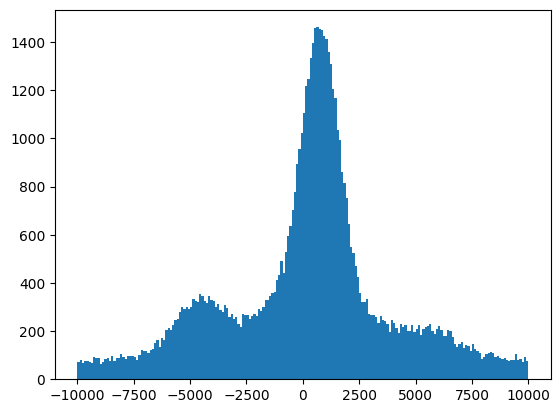

In [14]:
plt.hist(coincidences_arr_l[3], bins = 200)
plt.show()

In [17]:
# Create lookup table for each channel in l and r
lookup_l = np.asarray([0.0 for i in range(128)])
lookup_r = np.asarray([0.0 for i in range(128)])

# Define gaussian fit
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Left side
for l in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_l[l], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_l[l] = -1 * popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

# Right side
for r in range(128):
#for l in [0]:
    # Create histogram
    counts, bins = np.histogram(coincidences_arr_r[r], bins = 200)
    # Initial guess for amplitude
    inita = 0.8 * np.max(counts)
    # Initial guess for mean
    initmu = bins[:-1][np.where(counts == np.max(counts))[0][0]]
                
    try:
        # try fit, with bad stats the fit sometimes doesn't work
        popt = curve_fit(gaussian, bins[:-1], counts, p0 = [inita, initmu, 500])[0]
        # Check that mean is reasonable 
        if abs(popt[1]) < 10000: # 10000
            # write time offset to table as negative so that it can be ADDED when used
            lookup_r[r] = -1 * popt[1]
    except:
        pass

    #plt.hist(coincidences_arr_l[l], bins = 200)
    #plt.plot(np.linspace(-10000, 10000, 300), gaussian(np.linspace(-10000, 10000, 300), *popt), color = 'black')
    #print(*popt)

In [18]:
print(lookup_l)
print(lookup_r)

[-1.70905829e+02 -3.67288654e+02 -4.32492748e+02 -6.83148023e+02
  1.72956809e+03 -4.99316908e+02  2.45152641e+03 -7.64168519e+01
  2.01578276e+03  4.79835500e+02  4.45140940e+03 -1.06841514e+03
 -8.14439906e+02 -1.22733230e+02  4.41778716e+02  2.77895811e+03
  1.83494740e+03 -5.77388884e+02  1.43918697e+02 -4.18871422e+02
 -1.35458281e+03 -1.12625950e+02 -4.62396755e+02  5.00648438e+03
 -3.34726174e+02 -6.28542064e+01  1.41777538e+02 -9.64195082e+02
 -6.15018787e+02  3.12629929e+03  1.30780818e+02  7.79940006e+02
 -1.52255390e+02  1.42455473e+02  3.82292310e+02  8.76678522e+02
  2.74158434e+03 -2.47549989e+02  4.94501745e+02  3.36160190e+03
  6.66238825e+03  9.82251977e+02  1.02871470e+03  2.91429417e+02
  3.91343505e+03  7.42613829e+02 -2.23806834e+02  7.59422455e+02
  3.86580005e+02  4.22365618e+02  6.76378497e+02  1.91458064e+03
  3.54773941e+02 -6.68971888e+00  3.78472070e+02  6.70452940e+02
  2.43500439e+02  3.33679264e+02  4.80037441e+03  3.14284881e+03
 -4.67910278e+02  9.21321

In [20]:
def lookup(l, r):
    return lookup_l[l] / 2 + lookup_r[r] / 2

# Create master time difference array
master_time_diffs = []
for x in arr:
    master_time_diffs.append(x[6])

# Refill calibrated time difference array
master_time_diffs_calibrated = []
for x in arr:
    master_time_diffs_calibrated.append(x[6] + lookup(x[2], x[5]))

histogramlim = 15000

# Generate time difference histograms
if generate_time_difference_histograms:

    def formatlabel(a, mu, c):
        return f'a={round(a)}, mu={round(mu,1)}, sig={round(abs(c),1)}'

    # Histogram before time calibration
    hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)
    bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
    popt0 = curve_fit(gaussian, bincenters0, hist_before[0], p0 = [6000, 0, 1000])[0]
    #plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = formatlabel(*popt0))
    plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = 'before')
    print(popt0)

    # Histogram after time calibration
    hist_after = plt.hist(master_time_diffs_calibrated, bins=range(int(min(master_time_diffs_calibrated)), int(max(master_time_diffs_calibrated)) + binwidth, binwidth), color = 'blue', alpha = 0.4)
    bincenters1 = [(hist_after[1][x]+hist_after[1][x+1])/2 for x in range(len(hist_after[0]))]
    popt1 = curve_fit(gaussian, bincenters1, hist_after[0], p0 = [6000, 0, 1000])[0]
    #plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt1), color = 'blue', label = formatlabel(*popt1))
    plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt1), color = 'blue', label = 'after')
    print(popt1)

    plt.legend()
    plt.grid()
    plt.xlim(-1*histogramlim, histogramlim)
    plt.title('Time differences calibrated')
    plt.xlabel('Time difference (ps)')
    plt.ylabel('Counts')
    plt.savefig(output_dir + '/time_diffence_histograms.png')
    plt.close()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices